# Wikipedia Traffic Forecasting - KNN Baseline Walkthrough

This notebook walks the data pipeline and the KNN baseline for the traffic
forecasting project. The two deep models (an LSTM and a seq2seq causal CNN) live
in `src/` and train through `main.py`; they take a while, so this notebook stays
on the fast, fully-reproducible baseline: build the features, fit a nearest-
neighbours regressor, score it with SMAPE, and look at where it does badly.


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
from data_preprocessing import WikiTrafficPreprocessor
from knn_model import KNNTimeSeriesModel
from evaluation import TimeSeriesEvaluator

RNG = np.random.default_rng(42)

## Features

The preprocessor turns raw daily page views into a modelling table: a log
transform to tame the heavy tail, calendar features, and lag / rolling-window
features so each row carries its recent history. (Traffic is generated
synthetically here when no raw file is supplied, so the notebook runs anywhere.)

In [2]:
pre = WikiTrafficPreprocessor()
result = pre.preprocess_pipeline(sample_size=120)
data = result["data"]
print("rows:", len(data), "| columns:", data.shape[1])

Starting data preprocessing pipeline...
Found dataset file: validation_score.csv
Loading dataset from: /tmp/mllab/wikitraffic-forecasting/data/validation_score.csv


✅ Real dataset loaded successfully
Dataset shape: (145063, 18)
Columns: ['Unnamed: 0', 'median7', 'median14', 'median21', 'median28', 'median35', 'median42', 'median49', 'median7_h', 'median14_h', 'median21_h', 'median28_h', 'median35_h', 'median42_h', 'median49_h', 'holiday', 'holiday_log', 'yearly_log']
Detected validation_score.csv format - converting to time series format...
Converting validation score data to time series format...
Sampled 120 rows from dataset


Converted validation score data to time series format: (96360, 4)
Missing values handled using 'zero' strategy
Applied log(x + 1) transformation
Extracted temporal features: year, month, quarter, day_of_week, is_weekend, access_type


Created lag features for lags: [1, 7, 14, 30]
Created rolling statistics (mean, std) for windows: 7, 14, 30
Final dataset shape: (92760, 31)
rows: 92760 | columns: 31


In [3]:
# time-based split, then subsample for a quick baseline
X_train, X_test, y_train, y_test = pre.split_data(data, test_size=0.2)

def subsample(X, y, n):
    idx = RNG.choice(len(X), size=min(n, len(X)), replace=False)
    return X.iloc[idx], y[idx]

X_train, y_train = subsample(X_train, y_train, 6000)
X_test, y_test = subsample(X_test, y_test, 1500)
print("train:", X_train.shape, "test:", X_test.shape)

Prepared feature matrix with 28 features
Prepared feature matrix with 28 features
Data split: Train 74160, Test 18600
train: (6000, 28) test: (1500, 28)


## KNN baseline

Standard-scaled features, distance-weighted neighbours. Scaling lives inside the model so the test rows never touch the fitted scaler's statistics.

In [4]:
knn = KNNTimeSeriesModel(k=15, distance_metric="euclidean", weights="distance")
knn.fit(X_train, y_train, optimize_hyperparameters=False)
pred = knn.predict(X_test)

ev = TimeSeriesEvaluator()
metrics = ev.calculate_metrics(y_test, pred, "KNN")
print(f"SMAPE (original scale): {metrics['smape']:.2f}")
print(f"MAE (log scale):        {metrics['mae']:.4f}")
print(f"R2:                     {metrics['r2']:.3f}")

Training KNN model...
KNN model training completed!
SMAPE (original scale): 30.27
MAE (log scale):        0.2892
R2:                     0.905


## Predicted vs. actual

On the log scale, a good baseline should track the diagonal.

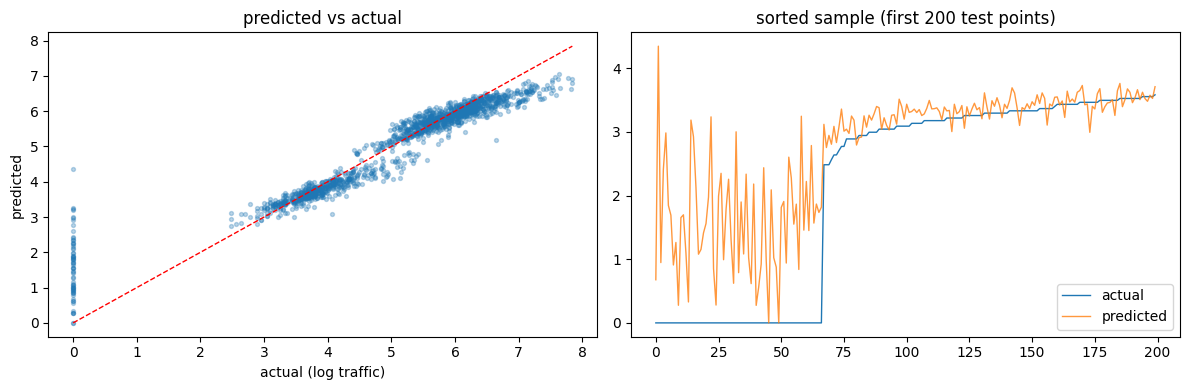

In [5]:
order = np.argsort(y_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, pred, s=8, alpha=0.3)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("actual (log traffic)"); axes[0].set_ylabel("predicted")
axes[0].set_title("predicted vs actual")

axes[1].plot(y_test[order][:200], label="actual", lw=1)
axes[1].plot(pred[order][:200], label="predicted", lw=1, alpha=0.8)
axes[1].set_title("sorted sample (first 200 test points)"); axes[1].legend()
plt.tight_layout(); plt.show()

## Anomaly view

The model also flags points that sit far from their neighbours - a cheap unsupervised anomaly signal that comes for free with KNN.

flagged 40 of 1500 points (2.7%) as far-from-neighbours


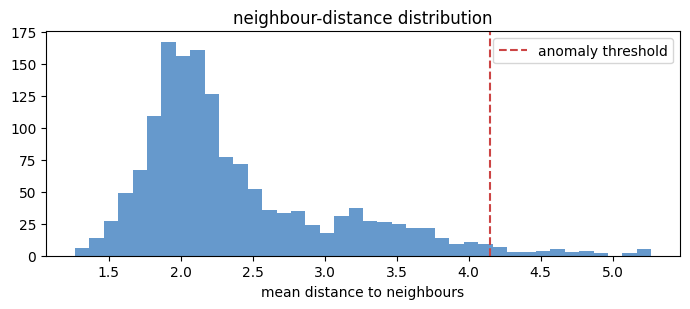

In [6]:
anom = knn.detect_anomalies(X_test, y_true=y_test, threshold_multiplier=2.5)
print(f"flagged {anom['num_anomalies']} of {len(X_test)} points "
      f"({anom['anomaly_rate']:.1f}%) as far-from-neighbours")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(anom["mean_distances"], bins=40, color="#69c")
ax.axvline(anom["threshold"], color="#c44", ls="--", label="anomaly threshold")
ax.set_xlabel("mean distance to neighbours"); ax.set_title("neighbour-distance distribution"); ax.legend()
plt.tight_layout(); plt.show()

## Where this fits

KNN is the honest baseline: no training curve, no tuning, and it already gives a
SMAPE the sequence models have to beat. Its weakness is that it treats each row
as an independent point rather than a sequence, which is exactly the gap the LSTM
and the causal CNN in `src/` are meant to close. Run `python src/main.py` to train
and compare all three end to end.
